In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_excel("/Users/senarajayawardena/Documents/Dialog/20260512_FintechTrainee_CaseStudy_Dataset_FinSightLanka_F.xlsx")


Data Cleaning

In [3]:
# Remove duplicates
dup_mask = df["Customer_ID"].duplicated() | df["NIC_Number"].duplicated()
df = df[dup_mask].reset_index(drop=True)
print(f"Removed {dup_mask.sum()} duplicates → {len(df):,} rows remain")

Removed 11 duplicates → 11 rows remain


In [6]:
# Gender
df["Gender"] = df["Gender"].str.strip().str.capitalize().replace({"M": "Male", "F": "Female"})

# Account Status
df["Account_Status"] = df["Account_Status"].str.strip().str.capitalize()

# District typos
df["District"] = df["District"].replace({"Columbo": "Colombo", "Kanady": "Kandy", "Gale": "Galle", "Jafna": "Jaffna"})

# Province from District
DISTRICT_TO_PROVINCE = {
    "Colombo": "Western", "Gampaha": "Western", "Kandy": "Central",
    "Badulla": "Uva", "Trincomalee": "Eastern", "Jaffna": "Northern",
    "Galle": "Southern", "Matara": "Southern", "Kurunegala": "North Western",
    "Ratnapura": "Sabaragamuwa",
}
df["Province"] = df["District"].map(DISTRICT_TO_PROVINCE).combine_first(df["Province"])

In [ ]:
# counts missing values per column and shows only columns that have at least one missing value,
# sorted by most missing first.

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
print(pd.DataFrame({"Count": missing, "%": missing_pct})
      .query("Count > 0")
      .sort_values("Count", ascending=False))

                          Count     %
FD_Amount                   358  70.5
Loan_Amount                 291  57.3
Loan_Tenure_Months          290  57.1
Monthly_Repayment_Amount    290  57.1
Loan_Type                   290  57.1
Outstanding_Loan_Balance    289  56.9
Loan_Start_Date             288  56.7
Loan_Repayment_Status       288  56.7
Referral_Source             252  49.6
Last_Login_Date             169  33.3
Full_Name                     8   1.6
KYC_Status                    7   1.4
Monthly_Deposit_Avg           6   1.2
Savings_Balance               6   1.2
District                      5   1.0
Has_Loan                      5   1.0
Customer_Segment              5   1.0


In [8]:
# Null out bad values
df.loc[df["Savings_Balance"] < 0, "Savings_Balance"] = np.nan
df.loc[df["Savings_Balance"] >= 999_000_000, "Savings_Balance"] = np.nan

# Impute with segment median
df["Savings_Balance"] = df.groupby("Customer_Segment")["Savings_Balance"] \
                          .transform(lambda x: x.fillna(x.median()))

In [9]:
# nulls out negative deposits (impossible), 
# fills missing deposits and withdrawals with their median, 
# then recalculates net flow.

# Fix deposits
df.loc[df["Monthly_Deposit_Avg"] < 0, "Monthly_Deposit_Avg"] = np.nan
df["Monthly_Deposit_Avg"] = df["Monthly_Deposit_Avg"].fillna(df["Monthly_Deposit_Avg"].median())

# Fix withdrawals
df["Monthly_Withdrawal_Avg"] = df["Monthly_Withdrawal_Avg"].fillna(df["Monthly_Withdrawal_Avg"].median())

# Recompute net flow
df["Net_Monthly_Flow"] = df["Monthly_Deposit_Avg"] - df["Monthly_Withdrawal_Avg"]

In [11]:
#fills missing Has_Loan based on whether Loan_Amount exists, 
#then checks that non-borrowers don't have any loan data filled in.


# Infer Has_Loan from Loan_Amount
mask = df["Has_Loan"].isna()
df.loc[mask & df["Loan_Amount"].notna(), "Has_Loan"] = "Yes"
df.loc[mask & df["Loan_Amount"].isna(),  "Has_Loan"] = "No"

# Check for spurious loan data on non-borrowers
loan_cols = ["Loan_Amount", "Loan_Tenure_Months", "Monthly_Repayment_Amount",
             "Outstanding_Loan_Balance", "Loan_Type", "Loan_Repayment_Status"]

spurious = df.loc[df["Has_Loan"] == "No", loan_cols].notna().sum()
print(spurious[spurious > 0])  # prints only problem columns

Loan_Amount                 1
Loan_Tenure_Months          1
Monthly_Repayment_Amount    1
Outstanding_Loan_Balance    2
Loan_Type                   1
Loan_Repayment_Status       3
dtype: int64


In [12]:
for col in ["Customer_Segment", "District", "KYC_Status"]:
    df[col] = df[col].fillna("Unknown")

In [14]:
#recalculates tenure from Account_Open_Date and overwrites the existing column
#(ignoring whatever was there before).

REF_DATE = pd.Timestamp("2026-05-01")
df["Customer_Tenure_Years"] = ((REF_DATE - df["Account_Open_Date"]).dt.days / 365.25).round(1)



In [15]:
#creates 5 new columns 
#age groups, debt-to-savings ratio, savings growth flag, cross-sell candidates, and high-risk flag.


# Age bands
df["Age_Band"] = pd.cut(df["Age"], bins=[17,24,34,44,54,64,100],
                        labels=["18-24","25-34","35-44","45-54","55-64","65+"])

# Debt-to-Savings (loan holders with positive savings only)
mask = (df["Has_Loan"] == "Yes") & df["Outstanding_Loan_Balance"].notna() & (df["Savings_Balance"] > 0)
df["Debt_to_Savings"] = np.where(mask, df["Outstanding_Loan_Balance"] / df["Savings_Balance"], np.nan)

# Savings growing
df["Savings_Growing"] = df["Net_Monthly_Flow"] > 0

# Cross-sell opportunity
df["CrossSell_Opportunity"] = (df["Savings_Balance"] > 0) & (df["Has_Fixed_Deposit"] == "No") & (df["Has_Insurance"] == "No")

# High risk
df["High_Risk_Flag"] = (df["Debt_to_Savings"] > 1.0) & (df["Loan_Repayment_Status"] == "Defaulted")


Age_BandGroups customers by age — e.g. 18-24, 25-34, etc. Useful for segment 
analysis

Debt_to_SavingsHow much loan debt a customer has relative to their savings. > 1.0 
means they owe more than they have saved — financially stressed

Savings_GrowingTrue if deposits > withdrawals that month — customer is saving more than spending

CrossSell_OpportunityTrue if customer has savings but no fixed deposit and no insurance — good candidate to sell those products to

High_Risk_FlagTrue if customer has more debt than savings AND has already defaulted — highest priority risk customers

In [17]:
#final sanity check — prints the cleaned dataframe's shape, how many rows were dropped, any remaining nulls, and column data types.

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Rows removed: {510 - len(df)}")  # replace 510 with your actual raw row count
print(df.isnull().sum()[df.isnull().sum() > 0])
print(df.dtypes)

Shape: 508 rows × 49 columns
Rows removed: 2
Full_Name                     8
Savings_Balance               5
Loan_Type                   290
Loan_Amount                 291
Loan_Tenure_Months          290
Monthly_Repayment_Amount    290
Loan_Repayment_Status       288
Loan_Start_Date             288
Outstanding_Loan_Balance    289
Last_Login_Date             169
FD_Amount                   358
Referral_Source             252
Age_Band                      3
Debt_to_Savings             293
dtype: int64
Customer_ID                          object
Full_Name                            object
NIC_Number                           object
Gender                               object
Date_of_Birth                datetime64[ns]
Age                                   int64
District                             object
Province                             object
Urban_Rural                          object
Customer_Segment                     object
Account_Open_Date            datetime64[ns]
Customer_T

In [18]:
df.to_csv("finsight_clean.csv", index=False)

EDA


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import os, warnings
warnings.filterwarnings("ignore")

os.makedirs("eda_output", exist_ok=True)

NAVY, BLUE, GREEN, AMBER, RED, GREY, LGREY = "#1B4F72","#2E86C1","#1E8449","#D4861A","#C0392B","#7F8C8D","#ECF0F1"
PALETTE_SEG  = {"Premium": NAVY, "Regular": BLUE, "Starter": AMBER, "Unknown": GREY}
PALETTE_CHAN  = {"Agent": NAVY, "Branch": BLUE, "Digital": GREEN, "Referral": AMBER}

fmt_lkr = lambda x, p=None: f"LKR {x/1e6:.1f}M" if x>=1e6 else f"LKR {x/1e3:.0f}K" if x>=1e3 else f"LKR {x:.0f}"
pct     = lambda n, d: 0 if d == 0 else round(100 * n / d, 1)

In [20]:
# Quick stats
print(f"Customers: {len(df):,} | Provinces: {df['Province'].nunique()} | Districts: {df['District'].nunique()}")
print(f"Avg tenure: {df['Customer_Tenure_Years'].mean():.1f} yrs | Total savings: LKR {df['Savings_Balance'].sum()/1e6:.1f}M")

# Value counts for key columns
for col in ["Customer_Segment", "Province", "Acquisition_Channel", "Account_Status", "KYC_Status"]:
    print(f"\n{col}:\n{df[col].value_counts().to_string()}")

Customers: 508 | Provinces: 8 | Districts: 11
Avg tenure: 6.8 yrs | Total savings: LKR 385.0M

Customer_Segment:
Customer_Segment
Regular    319
Starter     93
Premium     91
Unknown      5

Province:
Province
Western          105
Southern          82
Northern          59
Sabaragamuwa      58
North Western     56
Eastern           51
Uva               50
Central           47

Acquisition_Channel:
Acquisition_Channel
Referral    132
Digital     132
Branch      126
Agent       118

Account_Status:
Account_Status
Active       384
Inactive      81
Suspended     43

KYC_Status:
KYC_Status
Verified    358
Expired      73
Pending      70
Unknown       7


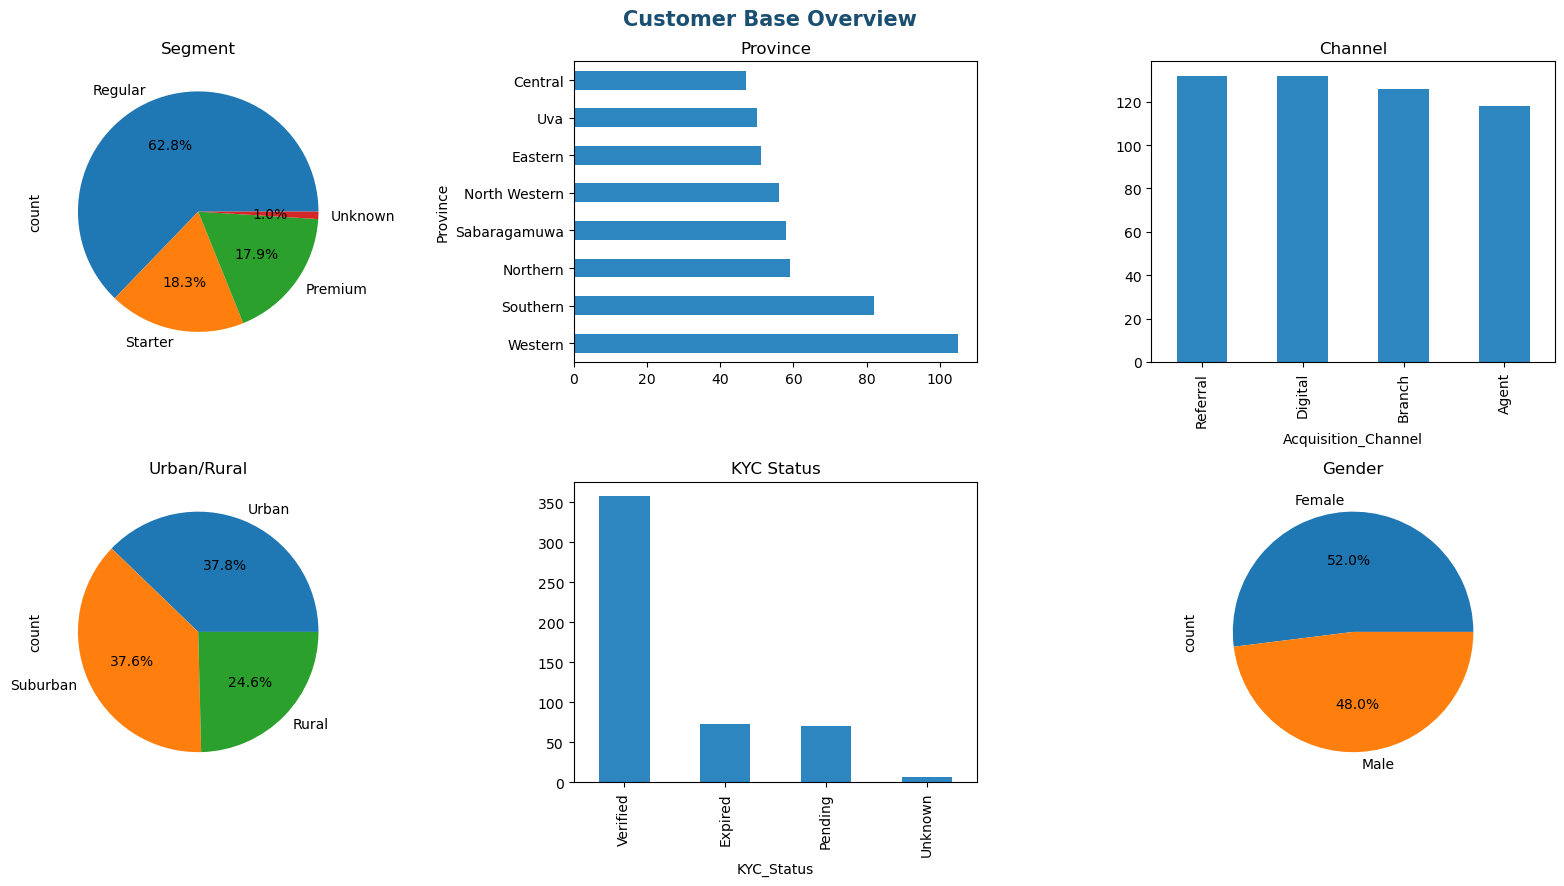

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Customer Base Overview", fontsize=15, fontweight="bold", color=NAVY)

df["Customer_Segment"].value_counts().plot.pie(ax=axes[0,0], autopct="%1.1f%%", title="Segment")
df["Province"].value_counts().plot.barh(ax=axes[0,1], title="Province", color=BLUE)
df["Acquisition_Channel"].value_counts().plot.bar(ax=axes[0,2], title="Channel", color=BLUE)
df["Urban_Rural"].value_counts().plot.pie(ax=axes[1,0], autopct="%1.1f%%", title="Urban/Rural")
df["KYC_Status"].value_counts().plot.bar(ax=axes[1,1], title="KYC Status", color=BLUE)
df["Gender"].value_counts().plot.pie(ax=axes[1,2], autopct="%1.1f%%", title="Gender")

plt.tight_layout()
plt.show()

         Age  Savings_Balance  Monthly_Deposit_Avg  Monthly_Withdrawal_Avg  \
count  508.0            503.0                508.0                   508.0   
mean    37.0         765456.2              37633.4                 59007.5   
std     12.1        1080667.3              57631.6                592686.2   
min      4.0           5945.0                194.8                   101.0   
25%     28.0         122290.3               5759.0                  3230.3   
50%     36.5         448866.7              17694.7                  9684.8   
75%     45.0         728410.7              39352.6                 22889.2   
max    150.0        4916005.1             347140.1               9999999.0   

       Net_Monthly_Flow  Customer_Tenure_Years  Monthly_Transaction_Count  
count             508.0                  508.0                      508.0  
mean           -21374.1                    6.8                       12.8  
std            594092.3                    2.7                       

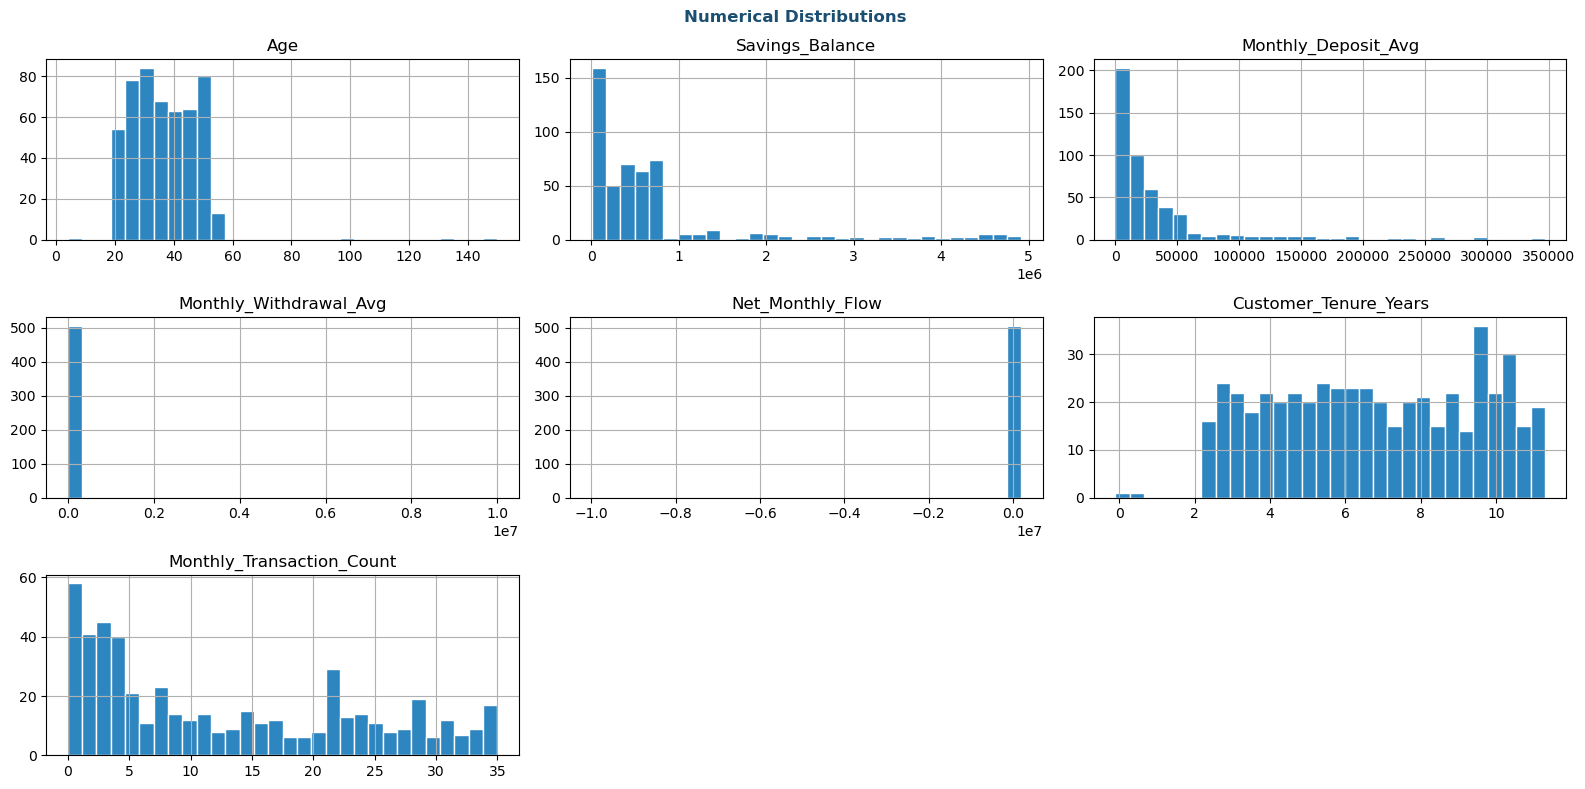

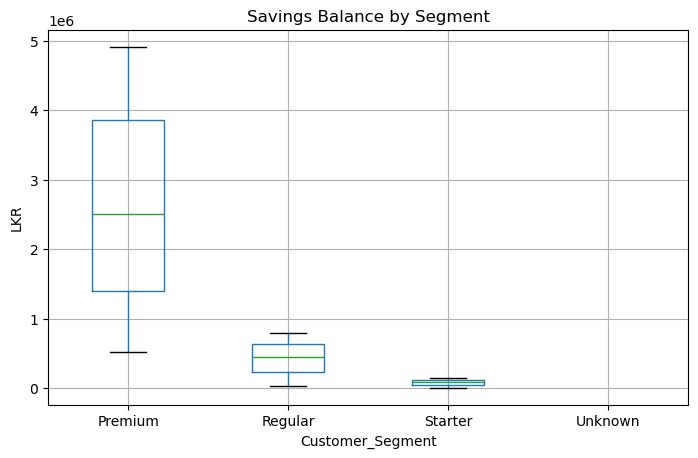

In [ ]:
#shows the distribution (spread, shape) of all numerical columns,
#then digs deeper into savings balance specifically.


num_cols = ["Age", "Savings_Balance", "Monthly_Deposit_Avg", "Monthly_Withdrawal_Avg",
            "Net_Monthly_Flow", "Customer_Tenure_Years", "Monthly_Transaction_Count"]

# Stats
print(df[num_cols].describe().round(1))

# Distributions
df[num_cols].hist(bins=30, figsize=(16, 8), color=BLUE, edgecolor="white")
plt.suptitle("Numerical Distributions", fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

# Savings by segment
df.boxplot(column="Savings_Balance", by="Customer_Segment", figsize=(8, 5))
plt.suptitle("")
plt.title("Savings Balance by Segment")
plt.ylabel("LKR")
plt.show()

                       mean     median  count
Customer_Segment                             
Premium           2654140.0  2504760.0     91
Regular            425859.0   448867.0    319
Starter             82246.0    85046.0     93
Unknown                 NaN        NaN      0
                   mean    median  count
Province                                
Central        726492.0  448867.0     47
Eastern        934620.0  540962.0     50
North Western  771320.0  510987.0     55
Northern       662592.0  398756.0     59
Sabaragamuwa   879928.0  409667.0     58
Southern       656488.0  379254.0     81
Uva            639433.0  420440.0     49
Western        837397.0  448582.0    104
                 mean    median  count
Urban_Rural                           
Rural        730859.0  418672.0    125
Suburban     665666.0  368721.0    189
Urban        888128.0  510987.0    189


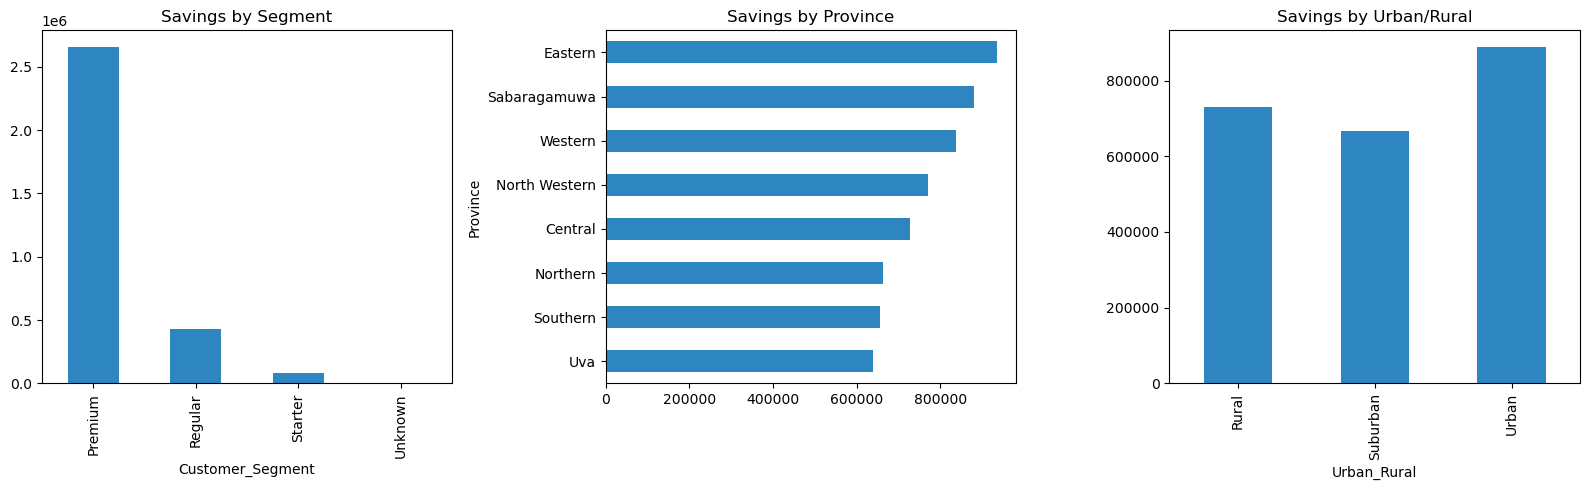

                  sum      mean    median  count
Age_Band                                        
18-24      48443626.0  712406.0  360107.0     68
25-34     126405239.0  826178.0  477761.0    153
35-44     116804853.0  794591.0  461148.0    147
45-54      91954743.0  701945.0  448867.0    131
65+           64002.0   64002.0   64002.0      1
Highest savings band: 25-34


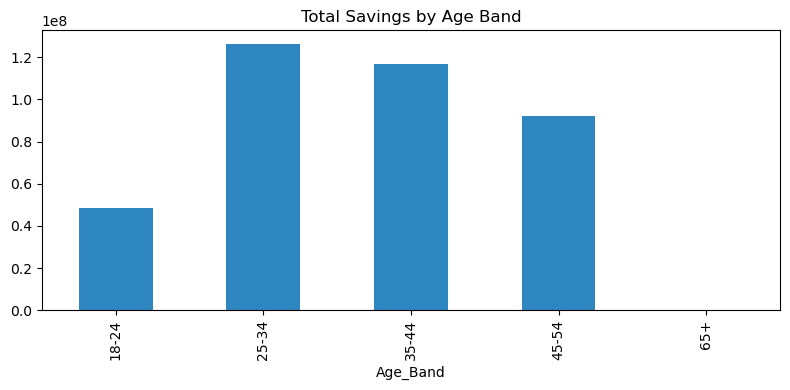

Flow_Category
Growing     503
Draining      5
Name: count, dtype: int64


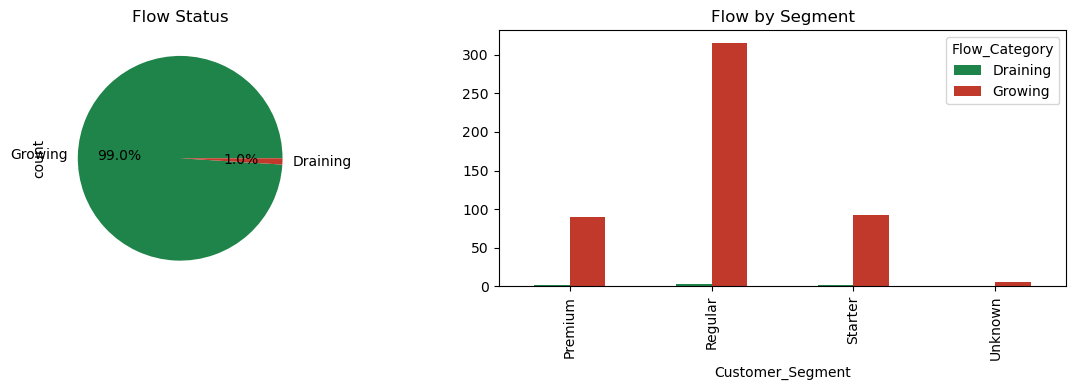

In [ ]:
#analyses savings by segment/province/urban-rural 
#by age band
#savings flow health.


#Savings by group
print(df.groupby("Customer_Segment")["Savings_Balance"].agg(["mean","median","count"]).round(0))
print(df.groupby("Province")["Savings_Balance"].agg(["mean","median","count"]).round(0))
print(df.groupby("Urban_Rural")["Savings_Balance"].agg(["mean","median","count"]).round(0))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
df.groupby("Customer_Segment")["Savings_Balance"].mean().plot.bar(ax=axes[0], color=BLUE, title="Savings by Segment")
df.groupby("Province")["Savings_Balance"].mean().sort_values().plot.barh(ax=axes[1], color=BLUE, title="Savings by Province")
df.groupby("Urban_Rural")["Savings_Balance"].mean().plot.bar(ax=axes[2], color=BLUE, title="Savings by Urban/Rural")
plt.tight_layout(); plt.show()

#Savings by age band
age_sav = df.groupby("Age_Band", observed=True)["Savings_Balance"].agg(["sum","mean","median","count"])
print(age_sav.round(0))
print(f"Highest savings band: {age_sav['sum'].idxmax()}")

age_sav["sum"].plot.bar(color=BLUE, title="Total Savings by Age Band", figsize=(8, 4))
plt.tight_layout(); plt.show()

#Savings flow
df["Flow_Category"] = np.where(df["Net_Monthly_Flow"] > 0, "Growing", "Draining")
print(df["Flow_Category"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["Flow_Category"].value_counts().plot.pie(ax=axes[0], autopct="%1.1f%%", colors=[GREEN, RED], title="Flow Status")
df.groupby(["Customer_Segment","Flow_Category"]).size().unstack().plot.bar(ax=axes[1], color=[GREEN,RED], title="Flow by Segment")
plt.tight_layout(); plt.show()

Overall loan penetration: 43.1%

D:S > 1.0 (owe more than they save): 126 customers
Avg D:S: 5.08 | Median: 1.66

Overall default rate: 10.1%  (target < 5%)


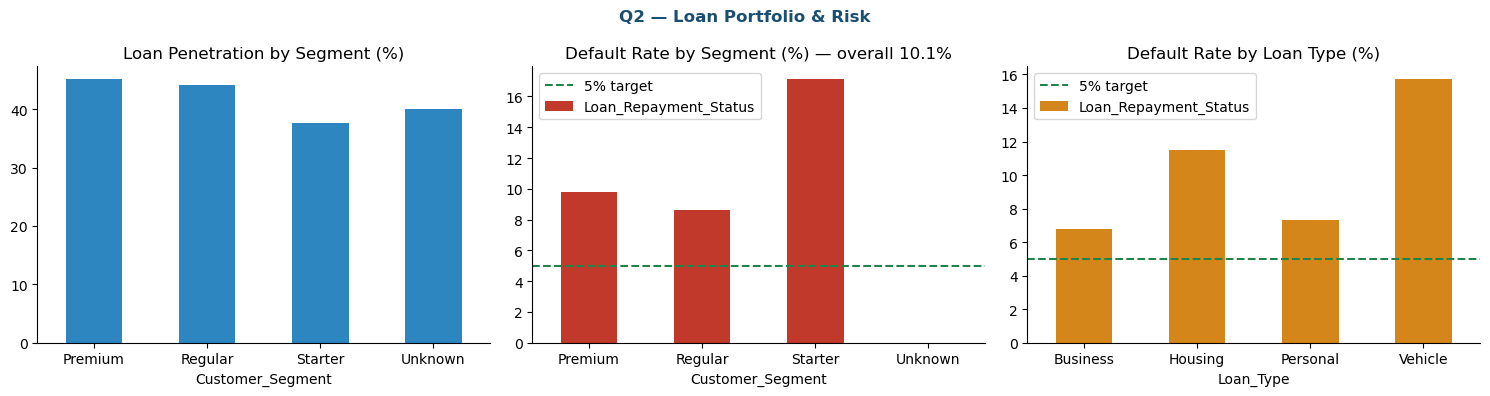

In [26]:
loan_df    = df[df["Has_Loan"] == "Yes"].copy()
loan_valid = loan_df[loan_df["Loan_Repayment_Status"].notna()]
dts        = loan_df[loan_df["Debt_to_Savings"].notna()]

#Penetration
print(f"Overall loan penetration: {pct((df['Has_Loan']=='Yes').sum(), len(df))}%")
seg_pen = df.groupby("Customer_Segment")["Has_Loan"].apply(lambda x: pct((x=="Yes").sum(), len(x)))
ch_pen  = df.groupby("Acquisition_Channel")["Has_Loan"].apply(lambda x: pct((x=="Yes").sum(), len(x)))

#Debt-to-Savings
print(f"\nD:S > 1.0 (owe more than they save): {(dts['Debt_to_Savings'] > 1.0).sum()} customers")
print(f"Avg D:S: {dts['Debt_to_Savings'].mean():.2f} | Median: {dts['Debt_to_Savings'].median():.2f}")

#Defaults
default_rate = pct((loan_valid["Loan_Repayment_Status"]=="Defaulted").sum(), len(loan_valid))
print(f"\nOverall default rate: {default_rate}%  (target < 5%)")
seg_def = loan_valid.groupby("Customer_Segment")["Loan_Repayment_Status"].apply(lambda x: pct((x=="Defaulted").sum(), len(x)))
lt_def  = loan_valid.groupby("Loan_Type")["Loan_Repayment_Status"].apply(lambda x: pct((x=="Defaulted").sum(), len(x)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Q2 — Loan Portfolio & Risk", fontweight="bold", color=NAVY)

seg_pen.plot.bar(ax=axes[0], color=BLUE, title="Loan Penetration by Segment (%)")
seg_def.plot.bar(ax=axes[1], color=RED,  title=f"Default Rate by Segment (%) — overall {default_rate}%")
axes[1].axhline(5, color=GREEN, linestyle="--", label="5% target"); axes[1].legend()
lt_def.plot.bar( ax=axes[2], color=AMBER, title="Default Rate by Loan Type (%)")
axes[2].axhline(5, color=GREEN, linestyle="--", label="5% target"); axes[2].legend()

for ax in axes:
    ax.tick_params(axis="x", rotation=0)
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout(); plt.show()

                     mean    median  count
Mobile_App_User                           
No               786483.0  444522.0    168
Yes              754912.0  448867.0    335

Cross-sell candidates: 255 (50.2%)
                  count       mean          sum
Customer_Segment                               
Premium              58  2668235.0  154757639.0
Regular             151   440104.0   66455730.0
Starter              46    87822.0    4039831.0
                         mean  count  Default_%
Acquisition_Channel                            
Agent                641858.4    118        5.4
Branch               836462.1    124       11.5
Digital              821605.4    131       11.1
Referral             753335.3    130       12.7


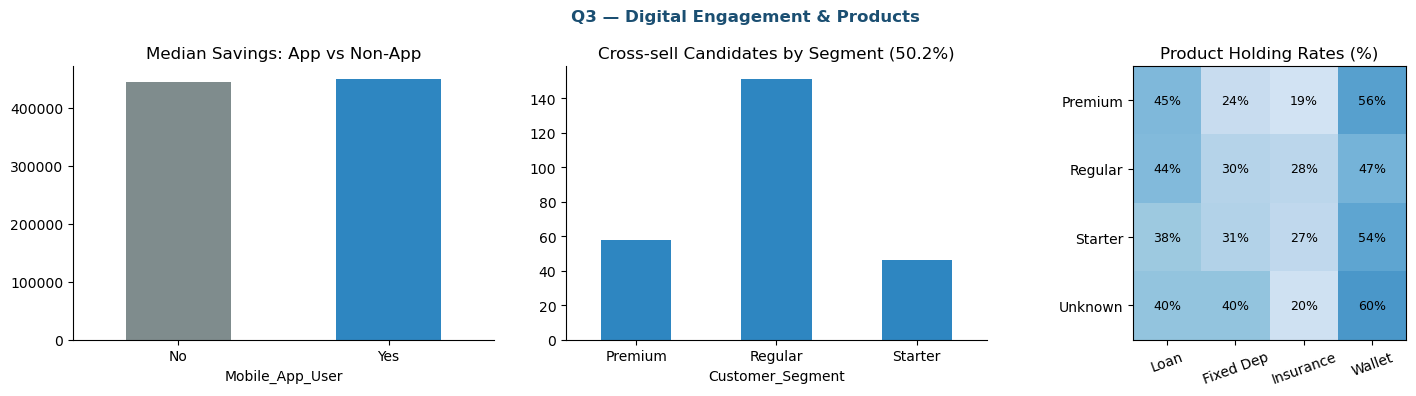

In [27]:
#App vs non-app
print(df.groupby("Mobile_App_User")["Savings_Balance"].agg(["mean","median","count"]).round(0))

#Cross-sell
xsell = df[df["CrossSell_Opportunity"]]
print(f"\nCross-sell candidates: {len(xsell):,} ({pct(len(xsell), len(df))}%)")
print(xsell.groupby("Customer_Segment")["Savings_Balance"].agg(["count","mean","sum"]).round(0))

#Channel quality
ch_qual = df.groupby("Acquisition_Channel")["Savings_Balance"].agg(["mean","count"])
ch_def  = loan_valid.groupby("Acquisition_Channel")["Loan_Repayment_Status"].apply(
            lambda x: pct((x=="Defaulted").sum(), len(x))).rename("Default_%")
print(ch_qual.join(ch_def).round(1))

# Charts
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Q3 — Digital Engagement & Products", fontweight="bold", color=NAVY)

df.groupby("Mobile_App_User")["Savings_Balance"].median().plot.bar(
    ax=axes[0], color=[GREY, BLUE], title="Median Savings: App vs Non-App")

xsell.groupby("Customer_Segment").size().plot.bar(
    ax=axes[1], color=BLUE, title=f"Cross-sell Candidates by Segment ({pct(len(xsell),len(df))}%)")

# Product holding heatmap
products = {"Loan":"Has_Loan", "Fixed Dep":"Has_Fixed_Deposit",
            "Insurance":"Has_Insurance", "Wallet":"Has_Mobile_Wallet"}
seg_prod = pd.DataFrame({
    label: df.groupby("Customer_Segment")[col].apply(lambda x: pct((x=="Yes").sum(), len(x)))
    for label, col in products.items()
})
im = axes[2].imshow(seg_prod.values, cmap="Blues", vmin=0, vmax=100)
axes[2].set_xticks(range(len(products))); axes[2].set_xticklabels(products.keys(), rotation=20)
axes[2].set_yticks(range(len(seg_prod))); axes[2].set_yticklabels(seg_prod.index)
for i in range(len(seg_prod)):
    for j in range(len(products)):
        axes[2].text(j, i, f"{seg_prod.values[i,j]:.0f}%", ha="center", va="center", fontsize=9)
axes[2].set_title("Product Holding Rates (%)")

for ax in axes[:2]:
    ax.tick_params(axis="x", rotation=0)
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout(); plt.show()

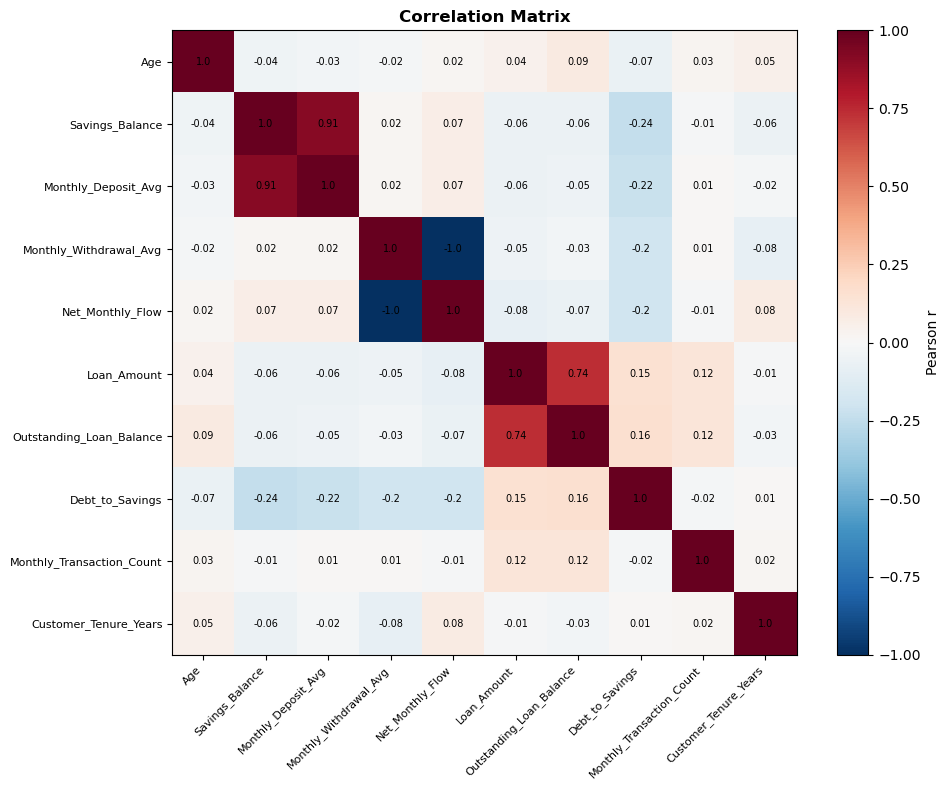

In [ ]:
#shows how strongly each numerical column is related to every other 
#values close to 1 or -1 mean strong relationship, close to 0 means no relationship.




corr_cols = ["Age", "Savings_Balance", "Monthly_Deposit_Avg", "Monthly_Withdrawal_Avg",
             "Net_Monthly_Flow", "Loan_Amount", "Outstanding_Loan_Balance",
             "Debt_to_Savings", "Monthly_Transaction_Count", "Customer_Tenure_Years"]

corr = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols, fontsize=8)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, corr.values[i,j], ha="center", va="center", fontsize=7)
plt.colorbar(im, ax=ax, label="Pearson r")
ax.set_title("Correlation Matrix", fontweight="bold")
plt.tight_layout(); plt.show()

✗ Loan Default Rate: 10.1%  (target <5%)
✗ Cross-Sell Gap: 50.2%  (target <35%)
✗ App Adoption: 66.7%  (target >75%)
✗ KYC Verified: 70.5%  (target >95%)
✓ Savings Growing: 99.0%  (target >70%)


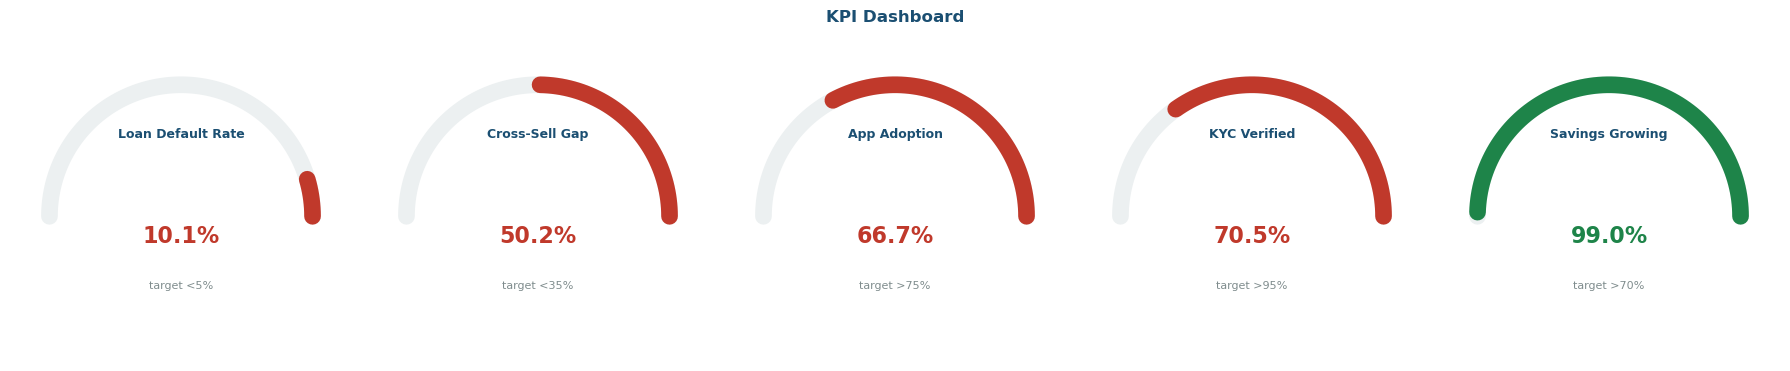

In [ ]:
#calculates 5 KPIs and shows them as gauge charts with targets and status.


kpi_data = [
    ("Loan Default Rate",    pct((loan_valid["Loan_Repayment_Status"]=="Defaulted").sum(), len(loan_valid)), 5,  "lower"),
    ("Cross-Sell Gap",       pct(df["CrossSell_Opportunity"].sum(), len(df)),                                35, "lower"),
    ("App Adoption",         pct((df["Mobile_App_User"]=="Yes").sum(), len(df)),                             75, "higher"),
    ("KYC Verified",         pct((df["KYC_Status"]=="Verified").sum(), len(df)),                             95, "higher"),
    ("Savings Growing",      pct((df["Net_Monthly_Flow"]>0).sum(), len(df)),                                 70, "higher"),
]

# Print summary
for name, value, target, direction in kpi_data:
    met = (value <= target) if direction == "lower" else (value >= target)
    print(f"{'✓' if met else '✗'} {name}: {value}%  (target {'<' if direction=='lower' else '>'}{target}%)")

# Chart
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle("KPI Dashboard", fontweight="bold", color=NAVY)

for ax, (name, value, target, direction) in zip(axes, kpi_data):
    color = GREEN if (value <= target if direction == "lower" else value >= target) else RED
    theta = np.linspace(0, np.pi, 100)
    ax.plot(np.cos(theta), np.sin(theta), color=LGREY, linewidth=12, solid_capstyle="round")
    ax.plot(np.cos(theta[:int(value)]), np.sin(theta[:int(value)]), color=color, linewidth=12, solid_capstyle="round")
    ax.text(0, -0.2, f"{value}%", ha="center", fontsize=16, fontweight="bold", color=color)
    ax.text(0,  0.6, name,        ha="center", fontsize=9,  fontweight="bold", color=NAVY)
    ax.text(0, -0.55, f"target {'<' if direction=='lower' else '>'}{target}%", ha="center", fontsize=8, color=GREY)
    ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.1, 1.1)
    ax.set_aspect("equal"); ax.axis("off")

plt.tight_layout(); plt.show()

In [ ]:
#flags compliance risks — suspicious activity, 
#politically exposed persons (PEP), high-risk borrowers, and inactive accounts.


print("Suspicious Activity:", df["Suspicious_Activity_Flag"].value_counts().to_dict())
print("PEP Flags:",           df["PEP_Flag"].value_counts().to_dict())
print("Account Status:",      df["Account_Status"].value_counts().to_dict())

print(f"\nHigh Risk Customers (D:S > 1 AND Defaulted): {df['High_Risk_Flag'].sum()}")
df[df["High_Risk_Flag"]][["Customer_ID","Customer_Segment","District",
                           "Savings_Balance","Outstanding_Loan_Balance","Debt_to_Savings","KYC_Status"]]

Suspicious Activity: {'No': 478, 'Yes': 30}
PEP Flags: {'No': 494, 'Yes': 14}
Account Status: {'Active': 384, 'Inactive': 81, 'Suspended': 43}

High Risk Customers (D:S > 1 AND Defaulted): 15


,Customer_ID,Customer_Segment,District,Savings_Balance,Outstanding_Loan_Balance,Debt_to_Savings,KYC_Status
9,FSL-0010,Starter,Kandy,85217.43,220632.73,2.589056,Pending
30,FSL-0031,Regular,Kandy,448866.68,2305593.61,5.136478,Verified
32,FSL-0033,Starter,Kurunegala,64176.80,1448399.40,22.568894,Verified
60,FSL-0061,Starter,Colombo,64001.58,652781.61,10.199461,Pending
100,FSL-0101,Premium,Gampaha,1224070.23,1311494.03,1.071421,Verified
203,FSL-0204,Regular,Galle,482677.41,1364330.88,2.826589,Pending
268,FSL-0269,Starter,Kurunegala,43546.19,1264320.82,29.034017,Expired
278,FSL-0279,Regular,Trincomalee,120223.85,1106135.90,9.200636,Verified
353,FSL-0354,Regular,Matara,658449.18,1454776.81,2.209399,Verified
362,FSL-0363,Starter,Kurunegala,33396.23,913744.15,27.360698,Verified
